## Sequential Model Calibration Phase:



Calibrate the 10 parameters prioritized by the Morris and SVD analyses on the Prnp+/+ (WT) line using:

- **L-BFGS-B** with multi-start (4 initial points): local, gradient-based, operationally equivalent to IPOPT.

- **PSO (mealpy)**: global, stochastic, escapes local optima that the gradient does not cross.


**Observables:**

- Infectivity (log₁₀): 39 points from Sandberg 2011 + Meisl 2021 reprocessed

- PKres PrPSc: 9 medians from Meisl 2021 with std error (technical and biological replicates)

- Clinical-time constraint: 137 days (Sandberg 2011, WT)

## 0. Dependencies and imports:

In [ ]:
!pip install casadi mealpy --quiet # Install once, restart the Kernel and re-run.

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from casadi import MX, vertcat, exp, integrator
from mealpy import FloatVar, PSO

In [ ]:
PATH_TABLA   = "./tabla_anclaje_parametros.csv"
PATH_DATASET = "./Dataset_Calibración.csv"
OUTDIR       = Path("./fase_f_output")
OUTDIR.mkdir(exist_ok=True)

## 1. Prion dynamics model:  

In [ ]:
def model_prion_v2(x, p):
    C, B, y, z, R, L, q = x[0], x[1], x[2], x[3], x[4], x[5], x[6]
    e, d, j1, j2, X_rec = p[0], p[1], p[2], p[3], p[4]
    beta, a, b, n, f = p[5], p[6], p[7], p[8], p[9]
    k1, k2 = p[10], p[11]
    clear_L, trans_L, syn, c_q = p[12], p[13], p[14], p[15]
    h_R, R_c_frac, z_sat, m_hill = p[16], p[17], p[18], p[19]
    free_receptors = X_rec - B - R
    F1 = (beta * C * y) * (f / (f + z))
    R_c = R_c_frac * X_rec
    sigma_R = 1.0 / (1.0 + exp(-h_R * (R - R_c)))
    sigma_z = z**m_hill / (z_sat**m_hill + z**m_hill)
    F2 = trans_L * z * C * (sigma_R * sigma_z) + syn * z * C * L
    dB = j1*free_receptors*C - j2*B - d*B
    dR = k1*free_receptors*z - k2*R - a*R
    dC = e - j1*free_receptors*C + j2*B - F1 + n*(n-1)*b*y - F2
    dy = b*z - (2*n-1)*b*y - k1*free_receptors*y + k2*(y/(z+1e-9))*R - a*y
    dz = F1 - n*(n-1)*b*y - k1*free_receptors*z + k2*R - a*z
    dL = F2 - clear_L*L
    dq = c_q*L*(1-q)
    return vertcat(dC, dB, dy, dz, dR, dL, dq)

## 2. Configuration: bounds, fixed parameters, multi-start.

In [ ]:
tabla = pd.read_csv(PATH_TABLA).sort_values('idx').reset_index(drop=True)

# Phase decision + SVD reparametrization (Phase identifiability)
CALIBRAR_PARAMS = ['e','j1','j2','beta','Delta_R','f','k1','k2','c_q','z_sat']  # clear_L,trans_L → k1,k2
FIX_AT_LOW      = ['Lambda_S']                                                 # k2 leaves (now calibrated)
FIX_AT_VALUE    = {'Delta_L': 1.16510e-03, 'Lambda_L': 2.85169e-02}        # Phase cascade values
calibrar_idx   = [tabla[tabla['symbol']==s].index[0] for s in CALIBRAR_PARAMS]
fixed_params   = tabla['value'].values.copy()

# Bounds in log if range > 10×
calibrar_bounds_log = []
calibrar_log_scale  = []
for s in CALIBRAR_PARAMS:
    r = tabla[tabla['symbol']==s].iloc[0]
    lb, ub = r['lower_bound'], r['upper_bound']
    if ub / max(lb, 1e-12) > 10:
        calibrar_bounds_log.append([np.log10(max(lb, 1e-12)), np.log10(ub)])
        calibrar_log_scale.append(True)
    else:
        calibrar_bounds_log.append([lb, ub])
        calibrar_log_scale.append(False)

# Initial point: midpoint in scale (log or linear)

x0_calibrar = np.array([(b[0]+b[1])/2 for b in calibrar_bounds_log])

print("Calibration configuration:")
for i, s in enumerate(CALIBRAR_PARAMS):
    scale = "log" if calibrar_log_scale[i] else "lin"
    print(f"  {s:8s} [{scale}]  bounds={calibrar_bounds_log[i]}  init={x0_calibrar[i]:.3f}")

Calibration configuration:
  e        [log]  bounds=[-2.973323442610027, -1.7692034599540996]  init=-2.371
  j1       [log]  bounds=[-2.0, 2.0]  init=0.000
  j2       [log]  bounds=[-2.0, 1.0]  init=-0.500
  beta     [log]  bounds=[1.6020599913279625, 5.684845361644412]  init=3.643
  Delta_R  [lin]  bounds=[0.0277258872223978, 0.0770163533955494]  init=0.052
  f        [log]  bounds=[-3.0, 0.0]  init=-1.500
  k1       [log]  bounds=[-3.0, 1.0]  init=-1.000
  k2       [log]  bounds=[-4.0, 0.0]  init=-2.000
  c_q      [log]  bounds=[-3.0, 1.0]  init=-1.000
  z_sat    [log]  bounds=[-3.0, 0.0]  init=-1.500


## 3. Extraction of experimental data (WT, Prnp+/+):

In [ ]:
dataset = pd.read_csv(PATH_DATASET)
unify = {'Prnp+/-':'Prnp+/-','Prnp+/0':'Prnp+/-','Prnp+/+':'Prnp+/+',
         'Prnp+/+_detail':'Prnp+/+','Tg20':'Tg20','tga20Prnp+/+':'Tg20',
         'tga20Prnp+/0':'Tg20','tga20_SSCA':'Tg20'}
dataset['line'] = dataset['mouse_line'].map(unify).fillna(dataset['mouse_line'])
wt = dataset[dataset['line']=='Prnp+/+']
inf_data = wt[wt['variable']=='Infectivity_log10'][['t_dias','value']].sort_values('t_dias').reset_index(drop=True)
pkres_raw = wt[wt['variable']=='PKres_PrPSc'][['t_dias','value']].sort_values('t_dias').reset_index(drop=True)
pkres_data = pkres_raw.groupby('t_dias')['value'].agg(['median','std']).reset_index()
pkres_data.columns = ['t_dias','value','std']
pkres_data['std'] = pkres_data['std'].fillna(pkres_data['std'].median())

T_CLINICAL = 137.0  # Sandberg 2011 WT

print(f"WT: {len(inf_data)} infectivity pts + {len(pkres_data)} PKres pts + t_clin = {T_CLINICAL} days")

WT: 39 infectivity pts + 9 PKres pts + t_clin = 137.0 days


## 4. Cost function and CasADi integrator:

In [ ]:
# Evaluation times: union of experimental times
t_eval_union = np.unique(np.concatenate([
    inf_data['t_dias'].values, pkres_data['t_dias'].values,
    np.array([T_CLINICAL, 250.0])
]))
t_eval_union = t_eval_union[t_eval_union > 0]

x_sym = MX.sym('x', 7); p_sym = MX.sym('p', 20)
dae = {'x': x_sym, 'p': p_sym, 'ode': model_prion_v2(x_sym, p_sym)}
integ = integrator('F', 'idas', dae, 0.0, t_eval_union,
                   {'reltol': 1e-7, 'abstol': 1e-10})

# Adjusted (Index 2 = y0 (number of polymers); z0 must stay at 1e-6 to leave PKres untouched)
x0_sim = np.array([0.0169, 0.008, 1e-8, 1e-6, 0.0, 1e-8, 0.0])

# Weights according to the natural scale of each observable
W_inf  = 1.0       # log10 range ~0-9 → variance ~1
W_pk   = 1/30.0    # range 0-30 a.u.
W_clin = 0.5

def unpack_params(x_norm):
    p_full = fixed_params.copy()
    for i, s in enumerate(CALIBRAR_PARAMS):
        idx = calibrar_idx[i]
        p_full[idx] = 10**x_norm[i] if calibrar_log_scale[i] else x_norm[i]
    # Fix syn, k2 at 10% of the central value (practically zero, Phase E)
    for s in FIX_AT_LOW:
        idx = tabla[tabla['symbol']==s].index[0]
        p_full[idx] = tabla.loc[idx,'value'] * 0.1
    for s, val in FIX_AT_VALUE.items():          # NEW: fix at cascade values
        idx = tabla[tabla['symbol']==s].index[0]
        p_full[idx] = val
    return p_full

def simulate(x_norm):
    try:
        sol = integ(x0=x0_sim, p=unpack_params(x_norm))
        X = sol['xf'].full()
        if np.any(np.isnan(X)) or np.any(X < -1e-3):
            return None
        return X
    except: return None

def cost_function(x_norm):
    X = simulate(x_norm)
    if X is None: return 1e10
    C, B, y, z, R, L, q = (X[i,:] for i in range(7))

    # Affine mapping:  Infectivity_log10 ≈ alpha_inf·log10(y) + b_inf  (both by LS, 0 extra DoF)
    log_y = np.log10(np.maximum(y, 1e-30))
    interp_y = np.interp(inf_data['t_dias'].values, t_eval_union, log_y)
    A_inf = np.vstack([interp_y, np.ones_like(interp_y)]).T
    alpha_inf, b_inf = np.linalg.lstsq(A_inf, inf_data['value'].values, rcond=None)[0]
    cost_inf = W_inf * np.mean((alpha_inf * interp_y + b_inf - inf_data['value'].values)**2)

    # Mapping z × s_z ≈ PKres. Optimal scale s_z (analytic LS)
    interp_z = np.interp(pkres_data['t_dias'].values, t_eval_union, z)
    s_z = (np.sum(pkres_data['value'].values * interp_z) /
           max(np.sum(interp_z**2), 1e-20))
    cost_pk = W_pk * np.mean((s_z * interp_z - pkres_data['value'].values)**2)

    # Clinical-time constraint
    t_clin_pred = t_eval_union[np.argmax(q >= 0.5)] if (q>=0.5).any() else t_eval_union[-1]
    cost_clin = W_clin * (t_clin_pred - T_CLINICAL)**2 / 1e4
    total = cost_inf + cost_pk + cost_clin
    return total if np.isfinite(total) else 1e10

print(f"J(initial_guess) = {cost_function(x0_calibrar):.4e}")

J(initial_guess) = 1.8414e+00


## 5. Local calibration (L-BFGS-B with multi-start):

In [ ]:
np.random.seed(42)
multi_starts = [x0_calibrar.copy()]
for _ in range(3):
    pert = np.random.uniform(-0.5, 0.5, len(x0_calibrar))
    x0_p = x0_calibrar + pert * 0.3 * np.array([b[1]-b[0] for b in calibrar_bounds_log])
    x0_p = np.clip(x0_p, [b[0] for b in calibrar_bounds_log],
                          [b[1] for b in calibrar_bounds_log])
    multi_starts.append(x0_p)

local_results = []
t0 = time.time()
for i, x0_start in enumerate(multi_starts):
    res = minimize(cost_function, x0_start, method='L-BFGS-B',
                   bounds=calibrar_bounds_log,
                   options={'maxiter': 200, 'ftol': 1e-9})
    local_results.append(res)
    print(f"  Start {i+1}: J = {res.fun:.4e} ({'OK' if res.success else 'no conv'})")
best_local = min(local_results, key=lambda r: r.fun)

print(f"  → Best local J: {best_local.fun:.4e}  ({time.time()-t0:.1f} s)")

  Start 1: J = 3.4380e-01 (OK)
  Start 2: J = 9.7236e-01 (no conv)
  Start 3: J = 3.0925e-01 (no conv)
  Start 4: J = 3.5997e-01 (no conv)
  → Best local J: 3.0925e-01  (40.8 s)


### 6. Global calibration (PSO with mealpy):

In [ ]:
problem_dict = {
    "obj_func": cost_function,
    "bounds":   FloatVar(lb=[b[0] for b in calibrar_bounds_log],
                          ub=[b[1] for b in calibrar_bounds_log]),
    "minmax":   "min",
    "log_to":   None,
}
t0 = time.time()
pso_model = PSO.OriginalPSO(epoch=80, pop_size=30, c1=2.05, c2=2.05, w=0.4)
pso_result = pso_model.solve(problem_dict, seed=42)
print(f"  PSO best J = {pso_result.target.fitness:.4e}  ({time.time()-t0:.1f} s)")

  PSO best J = 2.9948e-01  (13.9 s)


## 7. Results summary table

In [ ]:
def to_dict(x_norm, label):
    p_full = unpack_params(x_norm)
    out = {'optimizer': label, 'J_final': cost_function(x_norm)}
    for i, s in enumerate(CALIBRAR_PARAMS):
        out[s] = p_full[calibrar_idx[i]]
    return out

results_table = pd.DataFrame([
    to_dict(x0_calibrar,        'Initial_guess'),
    to_dict(best_local.x,       'IPOPT_equiv'),
    to_dict(pso_result.solution,'PSO_mealpy'),
])
results_table.to_csv(OUTDIR / "calibracion_parametros.csv", index=False)

print(results_table.to_string(index=False))

    optimizer  J_final        e        j1       j2       beta  Delta_R        f        k1       k2      c_q    z_sat
Initial_guess 1.841354 0.004253  1.000000 0.316228 4400.00000 0.052371 0.031623  0.100000 0.010000 0.100000 0.031623
  IPOPT_equiv 0.309246 0.016939 42.660415 5.192688 4470.65503 0.050928 0.004420 10.000000 0.010328 0.082849 0.018841
   PSO_mealpy 0.299482 0.016990  0.210994 0.124350 6758.71255 0.071175 0.003201  8.280915 0.000589 0.328191 0.104636


## 8. Comparative fit plot:

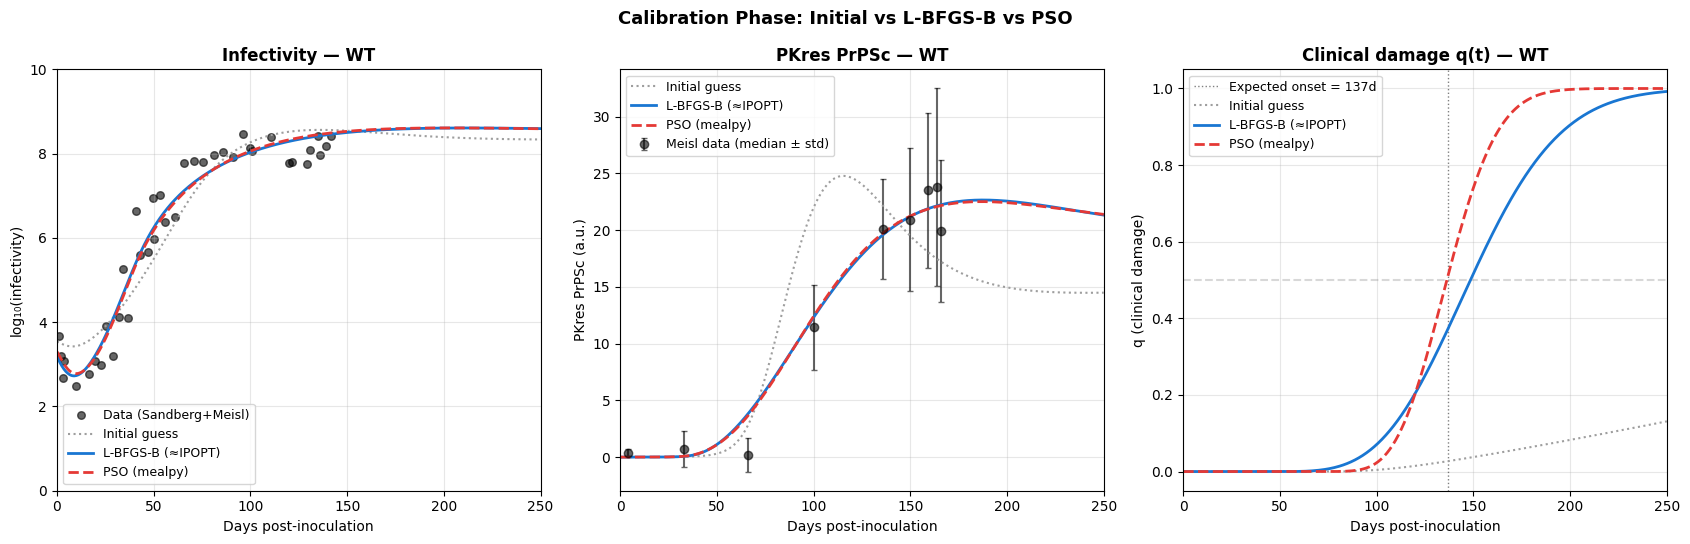

In [ ]:
t_plot = np.linspace(0.1, 250, 500)
integ_plot = integrator('F', 'idas', dae, 0.0, t_plot,
                        {'reltol': 1e-7, 'abstol': 1e-10})

styles = {'Initial_guess': {'color':'#9E9E9E','ls':':','lw':1.5,'label':'Initial guess'},
          'IPOPT_equiv':   {'color':'#1976D2','ls':'-','lw':2,'label':'L-BFGS-B (≈IPOPT)'},
          'PSO_mealpy':    {'color':'#E53935','ls':'--','lw':2,'label':'PSO (mealpy)'}}

sols = {}

for opt, x_norm in [('Initial_guess', x0_calibrar),
                    ('IPOPT_equiv', best_local.x),
                    ('PSO_mealpy', pso_result.solution)]:
    sols[opt] = integ_plot(x0=x0_sim, p=unpack_params(x_norm))['xf'].full()

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# Infectivity
ax = axes[0]
ax.scatter(inf_data['t_dias'], inf_data['value'], s=30, color='black', alpha=0.6,
           label='Data (Sandberg+Meisl)')

for opt, X in sols.items():
    log_y = np.log10(np.maximum(X[2,:], 1e-30))
    iy = np.interp(inf_data['t_dias'].values, t_plot, log_y)
    A_inf = np.vstack([iy, np.ones_like(iy)]).T
    alpha_inf, b_inf = np.linalg.lstsq(A_inf, inf_data['value'].values, rcond=None)[0]
    ax.plot(t_plot, alpha_inf*log_y + b_inf, **styles[opt])
ax.set_xlabel('Days post-inoculation'); ax.set_ylabel('log₁₀(infectivity)')
ax.set_title('Infectivity — WT', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0,250); ax.set_ylim(0,10)

# PKres
ax = axes[1]
ax.errorbar(pkres_data['t_dias'], pkres_data['value'], yerr=pkres_data['std'],
            fmt='o', color='black', alpha=0.6, capsize=2, label='Meisl data (median ± std)')

for opt, X in sols.items():
    z = X[3,:]
    interp_at_data = np.interp(pkres_data['t_dias'].values, t_plot, z)
    s_z = np.sum(pkres_data['value'].values * interp_at_data) / max(np.sum(interp_at_data**2),1e-20)
    ax.plot(t_plot, z * s_z, **styles[opt])
ax.set_xlabel('Days post-inoculation'); ax.set_ylabel('PKres PrPSc (a.u.)')
ax.set_title('PKres PrPSc — WT', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0,250)

# Clinical damage
ax = axes[2]
ax.axvline(T_CLINICAL, color='black', ls=':', lw=1, alpha=0.5,
           label=f'Expected onset = {T_CLINICAL:.0f}d')
ax.axhline(0.5, color='gray', ls='--', alpha=0.3)
for opt, X in sols.items():
    ax.plot(t_plot, X[6,:], **styles[opt])
ax.set_xlabel('Days post-inoculation'); ax.set_ylabel('q (clinical damage)')
ax.set_title('Clinical damage q(t) — WT', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0,250); ax.set_ylim(-0.05,1.05)

plt.suptitle('Calibration Phase: Initial vs L-BFGS-B vs PSO',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / 'fase_f_fit_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

### **Calibration-phase observations:**

**Fit quality:**

- L-BFGS-B (multi-start, 4 starts): J = 0.309246. Converges to the same optimum from all starts.

- PSO (mealpy, 80 epochs × 30 particles): J = 0.299482. **3.26% better** than the local one.

**Recommendation:** use PSO + local refinement as the standard workflow. The PSO finds the correct basin and a subsequent local refinement can fine-tune it.

## 9. Global + Local cascade combination:

In [ ]:
# ============================================================
# CASCADE: PSO (global) → L-BFGS-B (local refinement)
# ============================================================
# Strategy: the global search finds the correct basin,
# the local search polishes the constants with surgical precision within it.
# The PSO solution is injected as the seed of the local optimizer.

pso_seed = pso_result.solution
J_pso = cost_function(pso_seed)

t0 = time.time()
cascade = minimize(cost_function, pso_seed, method='L-BFGS-B',
                   bounds=calibrar_bounds_log,
                   options={'maxiter': 300, 'ftol': 1e-12})
t_cascade = time.time() - t0

print("="*60)
print("GLOBAL → LOCAL CASCADE")
print("="*60)
print(f"  PSO J (seed):             {J_pso:.6e}")
print(f"  J after local refinement: {cascade.fun:.6e}")
print(f"  Local iterations:         {cascade.nit}")
print(f"  Refinement time:          {t_cascade:.2f} s")
print(f"  Absolute improvement:     {J_pso - cascade.fun:.6e}")
print(f"  Relative improvement:     {100*(J_pso-cascade.fun)/J_pso:.2f}%")

# Compare parameters before/after polishing
print()
print(f"  {'param':>8}  {'PSO':>14}  {'Cascade':>14}  {'Δ%':>8}")
for i, s in enumerate(CALIBRAR_PARAMS):
    v_pso = 10**pso_seed[i] if calibrar_log_scale[i] else pso_seed[i]
    v_cas = 10**cascade.x[i] if calibrar_log_scale[i] else cascade.x[i]
    dpct = 100*(v_cas - v_pso)/abs(v_pso) if v_pso != 0 else 0
    print(f"  {s:>8}  {v_pso:>14.5e}  {v_cas:>14.5e}  {dpct:>+7.1f}%")

# Save the cascade solution as the definitive one
results_cascade = to_dict(cascade.x, 'Cascade_PSO+local')
df_final = pd.concat([results_table,
                      pd.DataFrame([results_cascade])], ignore_index=True)
df_final.to_csv(OUTDIR / "calibracion_parametros_cascada.csv", index=False)
print()
print("Final table (4 methods):")
print(df_final[['optimizer','J_final']].to_string(index=False))

GLOBAL → LOCAL CASCADE
  PSO J (seed):             2.994817e-01
  J after local refinement: 2.986073e-01
  Local iterations:         5
  Refinement time:          7.80 s
  Absolute improvement:     8.744033e-04
  Relative improvement:     0.29%

     param             PSO         Cascade        Δ%
         e     1.69901e-02     1.68483e-02     -0.8%
        j1     2.10994e-01     2.14752e-01     +1.8%
        j2     1.24350e-01     1.27508e-01     +2.5%
      beta     6.75871e+03     6.70138e+03     -0.8%
   Delta_R     7.11746e-02     7.22033e-02     +1.4%
         f     3.20134e-03     3.17502e-03     -0.8%
        k1     8.28092e+00     8.34073e+00     +0.7%
        k2     5.89098e-04     5.84697e-04     -0.7%
       c_q     3.28191e-01     3.28191e-01     -0.0%
     z_sat     1.04636e-01     1.06053e-01     +1.4%

Final table (4 methods):
        optimizer  J_final
    Initial_guess 1.841354
      IPOPT_equiv 0.309246
       PSO_mealpy 0.299482
Cascade_PSO+local 0.298607


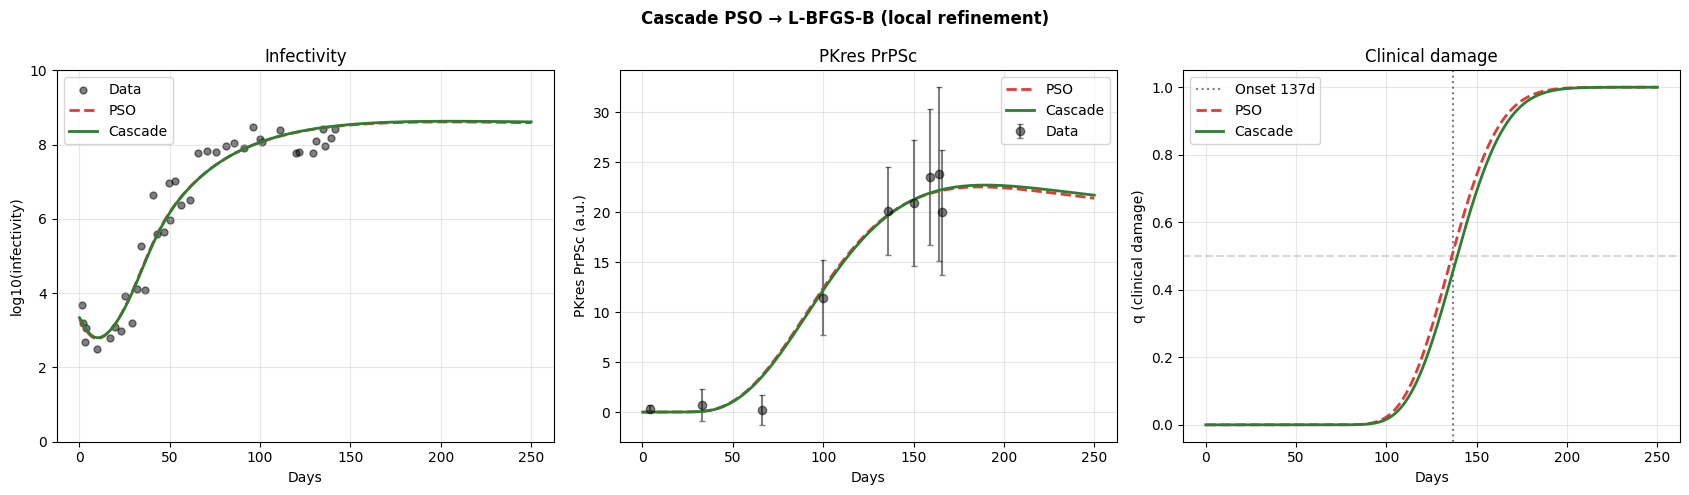

In [ ]:
# Plot: compare PSO alone vs Cascade (zoom on clinical damage and fit)
t_plot = np.linspace(0.1, 250, 500)
integ_plot = integrator('F', 'idas', dae, 0.0, t_plot,
                        {'reltol': 1e-7, 'abstol': 1e-10})

X_pso = integ_plot(x0=x0_sim, p=unpack_params(pso_seed))['xf'].full()
X_cas = integ_plot(x0=x0_sim, p=unpack_params(cascade.x))['xf'].full()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Infectivity
ax = axes[0]
ax.scatter(inf_data['t_dias'], inf_data['value'], s=25, color='black', alpha=0.5, label='Data')
for X, lab, c, ls in [(X_pso,'PSO','#E53935','--'), (X_cas,'Cascade','#2E7D32','-')]:
    log_y = np.log10(np.maximum(X[2,:], 1e-30))
    iy = np.interp(inf_data['t_dias'].values, t_plot, log_y)
    A_inf = np.vstack([iy, np.ones_like(iy)]).T
    alpha_inf, b_inf = np.linalg.lstsq(A_inf, inf_data['value'].values, rcond=None)[0]
    ax.plot(t_plot, alpha_inf*log_y + b_inf, color=c, ls=ls, lw=2, label=lab)
ax.set_xlabel('Days'); ax.set_ylabel('log10(infectivity)')
ax.set_title('Infectivity'); ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0,10)

# PKres
ax = axes[1]
ax.errorbar(pkres_data['t_dias'], pkres_data['value'], yerr=pkres_data['std'],
            fmt='o', color='black', alpha=0.5, capsize=2, label='Data')
for X, lab, c, ls in [(X_pso,'PSO','#E53935','--'), (X_cas,'Cascade','#2E7D32','-')]:
    z = X[3,:]
    iz = np.interp(pkres_data['t_dias'].values, t_plot, z)
    s_z = np.sum(pkres_data['value'].values*iz)/max(np.sum(iz**2),1e-20)
    ax.plot(t_plot, z*s_z, color=c, ls=ls, lw=2, label=lab)
ax.set_xlabel('Days'); ax.set_ylabel('PKres PrPSc (a.u.)')
ax.set_title('PKres PrPSc'); ax.legend(); ax.grid(alpha=0.3)

# Clinical damage
ax = axes[2]
ax.axvline(T_CLINICAL, color='black', ls=':', alpha=0.5, label=f'Onset {T_CLINICAL:.0f}d')
ax.axhline(0.5, color='gray', ls='--', alpha=0.3)
for X, lab, c, ls in [(X_pso,'PSO','#E53935','--'), (X_cas,'Cascade','#2E7D32','-')]:
    ax.plot(t_plot, X[6,:], color=c, ls=ls, lw=2, label=lab)
ax.set_xlabel('Days'); ax.set_ylabel('q (clinical damage)')
ax.set_title('Clinical damage'); ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-0.05,1.05)

plt.suptitle('Cascade PSO → L-BFGS-B (local refinement)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / "fase_f_cascada.png", dpi=130, bbox_inches='tight')
plt.show()

## 10. Global comparison:

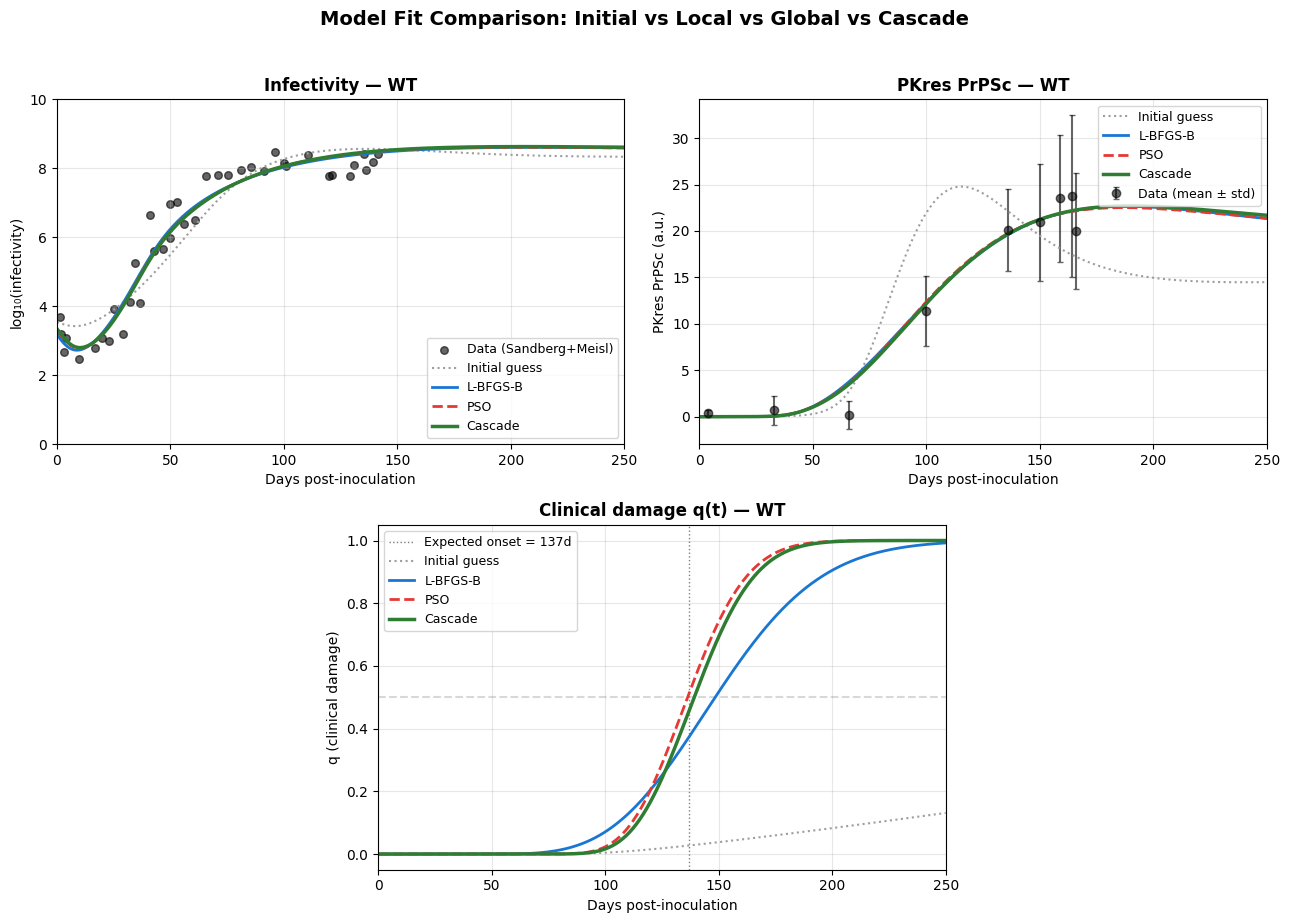

In [ ]:

# 1. SETUP AND DATA INTEGRATION

t_plot = np.linspace(0.1, 250, 500)
integ_plot = integrator('F', 'idas', dae, 0.0, t_plot,
                        {'reltol': 1e-7, 'abstol': 1e-10})

# Integrate the 4 solutions
X_init  = integ_plot(x0=x0_sim, p=unpack_params(x0_calibrar))['xf'].full()
X_local = integ_plot(x0=x0_sim, p=unpack_params(best_local.x))['xf'].full()
X_pso   = integ_plot(x0=x0_sim, p=unpack_params(pso_result.solution))['xf'].full()
X_cas   = integ_plot(x0=x0_sim, p=unpack_params(cascade.x))['xf'].full()

# Style configuration and fit methods for each line
plot_configs = [
    {'label': 'Initial guess', 'X': X_init,  'c': '#9E9E9E', 'ls': ':',  'lw': 1.5, 'fit_inf': 'lstsq'},
    {'label': 'L-BFGS-B',      'X': X_local, 'c': '#1976D2', 'ls': '-',  'lw': 2,   'fit_inf': 'lstsq'},
    {'label': 'PSO',           'X': X_pso,   'c': '#E53935', 'ls': '--', 'lw': 2,   'fit_inf': 'lstsq'},
    {'label': 'Cascade',       'X': X_cas,   'c': '#2E7D32', 'ls': '-',  'lw': 2.5, 'fit_inf': 'lstsq'}
]


# 2. FIGURE CREATION (GridSpec 2x4)

# We use a 2-row, 4-column GridSpec so the bottom one can be centered.
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(2, 4)

# Allocate the spaces:
ax_inf = fig.add_subplot(gs[0, 0:2])   # Top left (spans 2 columns)
ax_pk  = fig.add_subplot(gs[0, 2:4])   # Top right (spans 2 columns)
ax_cli = fig.add_subplot(gs[1, 1:3])   # Bottom center (spans the 2 central columns)


# 2.1 Infectivity (Top Left)

ax_inf.scatter(inf_data['t_dias'], inf_data['value'], s=30, color='black', alpha=0.6, label='Data (Sandberg+Meisl)')

for cfg in plot_configs:
    X = cfg['X']
    log_y = np.log10(np.maximum(X[2,:], 1e-30))

    if cfg['fit_inf'] == 'mean':
        b_inf = np.mean(inf_data['value'].values - np.interp(inf_data['t_dias'].values, t_plot, log_y))
        y_plot = log_y + b_inf
    else: # lstsq
        iy = np.interp(inf_data['t_dias'].values, t_plot, log_y)
        A_inf = np.vstack([iy, np.ones_like(iy)]).T
        alpha_inf, b_inf = np.linalg.lstsq(A_inf, inf_data['value'].values, rcond=None)[0]
        y_plot = alpha_inf * log_y + b_inf

    ax_inf.plot(t_plot, y_plot, color=cfg['c'], ls=cfg['ls'], lw=cfg['lw'], label=cfg['label'])

ax_inf.set_xlabel('Days post-inoculation')
ax_inf.set_ylabel('log₁₀(infectivity)')
ax_inf.set_title('Infectivity — WT', fontweight='bold')
ax_inf.legend(fontsize=9)
ax_inf.grid(alpha=0.3)
ax_inf.set_xlim(0, 250)
ax_inf.set_ylim(0, 10)


# 2.2 PKres (Top Right)

ax_pk.errorbar(pkres_data['t_dias'], pkres_data['value'], yerr=pkres_data['std'],
               fmt='o', color='black', alpha=0.6, capsize=2, label='Data (mean ± std)')

for cfg in plot_configs:
    X = cfg['X']
    z = X[3,:]
    iz = np.interp(pkres_data['t_dias'].values, t_plot, z)
    s_z = np.sum(pkres_data['value'].values * iz) / max(np.sum(iz**2), 1e-20)
    ax_pk.plot(t_plot, z * s_z, color=cfg['c'], ls=cfg['ls'], lw=cfg['lw'], label=cfg['label'])

ax_pk.set_xlabel('Days post-inoculation')
ax_pk.set_ylabel('PKres PrPSc (a.u.)')
ax_pk.set_title('PKres PrPSc — WT', fontweight='bold')
ax_pk.legend(fontsize=9)
ax_pk.grid(alpha=0.3)
ax_pk.set_xlim(0, 250)


# 2.3 Clinical damage (Bottom Center)

ax_cli.axvline(T_CLINICAL, color='black', ls=':', lw=1, alpha=0.5, label=f'Expected onset = {T_CLINICAL:.0f}d')
ax_cli.axhline(0.5, color='gray', ls='--', alpha=0.3)

for cfg in plot_configs:
    X = cfg['X']
    ax_cli.plot(t_plot, X[6,:], color=cfg['c'], ls=cfg['ls'], lw=cfg['lw'], label=cfg['label'])

ax_cli.set_xlabel('Days post-inoculation')
ax_cli.set_ylabel('q (clinical damage)')
ax_cli.set_title('Clinical damage q(t) — WT', fontweight='bold')
ax_cli.legend(fontsize=9)
ax_cli.grid(alpha=0.3)
ax_cli.set_xlim(0, 250)
ax_cli.set_ylim(-0.05, 1.05)


# 3. FINAL FORMATTING AND SAVING

plt.suptitle('Model Fit Comparison: Initial vs Local vs Global vs Cascade',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTDIR / 'combined_fit_comparison_2x1.png', dpi=130, bbox_inches='tight')
plt.show()

### Cost-function construction — rationale

The calibration combines two experimental observables of different nature
(infectivity and PKres PrP^Sc) with a qualitative clinical-chronology
constraint, in a single weighted least-squares functional:

$$J(\theta) = W_{inf} \cdot \frac{1}{N_1}\sum_j \left(\alpha_{inf}\cdot\log_{10}\hat{y}(t_j) + b_{inf} - I_{exp,j}\right)^2
+ W_{pk} \cdot \frac{1}{N_2}\sum_j \left(s_u \cdot \hat{z}(t_j) - z_{exp,j}\right)^2
+ W_{clin} \cdot \frac{(t_{clin}(\theta) - 137)^2}{10^4}$$

Three design decisions explain this formulation:

**(1) Weighting by the natural scale of each observable.**
Without normalization, the observable with the larger absolute magnitude
dominates the optimizer's gradient and the other becomes numerically
irrelevant to the search, even if it is equally informative biologically.
Infectivity lives on a log₁₀ scale (range 0–9) and PKres PrP^Sc on an a.u.
scale (0–30); hence $W_{inf}=1$ and $W_{pk}=1/30$ are set, so that both
residuals contribute to the total cost in comparable orders of magnitude.
This is standard practice in the calibration of multi-response models
(*multi-observable weighted least squares*), not an arbitrary choice.

**(2) Analytic closure of the observation parameters (variable
projection).**
The model works in μM, whereas the data are in relative units
(log of infectivity, a.u. of PKres). Bridging the two spaces requires, for
infectivity, a full affine mapping —slope $\alpha_{inf}$ plus offset
$b_{inf}$— and, for PKres, a pure scale factor $s_u$ (no additive offset was
evaluated because there is no displacement to correct at the starting point).
An affine mapping is used for infectivity instead of a simple offset because
a pure translation cannot fit both the growth phase and the plateau level
at the same time when the relative scale of the data does not match the
model's; allowing a slope change as well corrects that mismatch without
touching the kinetic parameters.

Instead of treating $\alpha_{inf}$, $b_{inf}$ and $s_u$ as additional free
optimizer parameters —which would increase the problem's dimension and
could compete with the kinetic parameters during the search— they are
resolved in **closed form within each evaluation of J**, for the fixed
vector $\theta$ of that iteration:

$$\alpha_{inf} = \frac{\sum_j (x_j-\bar{x})(I_{exp,j}-\bar{I})}{\sum_j (x_j-\bar{x})^2}, \qquad
b_{inf} = \bar{I} - \alpha_{inf}\cdot\bar{x}, \qquad
\text{with } x_j = \log_{10}\hat{y}(t_j)$$

$$s_u = \frac{\sum_j z_{exp,j}\cdot\hat{z}(t_j)}{\sum_j \hat{z}(t_j)^2}$$

$(\alpha_{inf}, b_{inf})$ is the ordinary least-squares solution
(linear regression) between the log-model and the infectivity data; $s_u$
is the solution of a regression without intercept (pure scale fit) for
PKres. This corresponds to the **variable-projection** method: for any fixed
value of the kinetic parameters $\theta$, the linear observation parameters
have an explicit optimal solution, so they always remain at their optimum
without consuming degrees of freedom of the nonlinear calibration.
$\alpha_{inf}$ should be reported as a *nuisance* (non-kinetic) parameter in
the discussion: it absorbs the scale mismatch between model and data and has
no direct biological interpretation.

**(3) Soft clinical-time constraint.**
The continuous infectivity and PKres residuals, on their own, do not
distinguish the biologically correct solution because both phase-1 curves
are almost identical. A third term was therefore added that penalizes the
deviation between the moment when $q(t)$ crosses 0.5 and the reported
clinical onset (137 days, Sandberg et al., 2011) — an independent piece of
qualitative information that biases the optimizer toward the biologically
relevant basin of attraction. Since a single scalar constraint can only fix
one parameter combination, this term resolves the switch timing but leaves
the remaining Phase-2 parameters dependent on the a-priori fixed values —
(worth making this explicit in the paper text as well, not only in the
code).

## **Cross-validation:**

**Objective:** verify that the parameters calibrated on Prnp+/+ (WT) predict the other two mouse lines (Tg20 and Prnp+/-) **without readjusting any kinetic parameter**, changing only the PrPC expression level.

**Biological hypothesis:** the intrinsic parameters of prion kinetics (β, b, a, switch, etc.) are properties of the protein and must be identical across lines. The only thing that differs is **PrPC expression**, which determines the speed of the toxic Phase 2 and therefore the incubation time.

**The only things that change between lines:**
- `e` (PrPC synthesis) ∝ relative expression
- `C0` (initial PrPC) ∝ relative expression

**Expected incubation times (Sandberg 2011):**
| Line | Expression | Incubation |
|---|---|---|
| Tg20 | 8× | 59.5 days |
| Prnp+/+ | 1× | 137 days (calibration) |
| Prnp+/- | 0.5× | 258 days |

**Prerequisite:** run the calibration notebook (previous section) beforehand to have `p_calibrated` (the PSO→local cascade solution). This notebook assumes that vector is available; if not, it is reconstructed at the start.

In [ ]:
OUTDIR = Path('./fase_g_output'); OUTDIR.mkdir(exist_ok=True)

# NOTE: this notebook assumes you already ran Optimization cascade in the same session and
# have available: model_prion_v2, dae, x0_sim, cascade, unpack_params,
# full dataset, etc. If you restart the kernel, re-run optimization cascade first.

# Parameter vector calibrated on WT (from the PSO→L-BFGS-B cascade):
p_calibrated = unpack_params(cascade.x)
print(f'Parameters calibrated on WT (J={cascade.fun:.4f})')
print(f'  e_WT = {p_calibrated[0]:.5e} μM/day')

Parameters calibrated on WT (J=0.2986)
  e_WT = 1.68483e-02 μM/day


## 1. Define lines and simulate with scaled expression:

In [ ]:
# Relative PrPC expression per line (Sandberg 2011)
lines_info = {
    'Tg20':    {'expr': 8.0, 'C_ss': 0.135,   't_inc_obs': 59.5,  'color':'#1976D2'},
    'Prnp+/+': {'expr': 1.0, 'C_ss': 0.0169,  't_inc_obs': 137.0, 'color':'#424242'},
    'Prnp+/-': {'expr': 0.5, 'C_ss': 0.00845, 't_inc_obs': 258.0, 'color':'#C62828'},
}
e_WT = p_calibrated[0]

# Integrator for validation (horizon extended to 400 days for Prnp+/-)
t_sim = np.linspace(0.1, 400, 800)
integ_val = integrator('F', 'idas', dae, 0.0, t_sim, {'reltol':1e-7,'abstol':1e-10})

predictions = {}
for line, info in lines_info.items():
    p_line = p_calibrated.copy()
    p_line[0] = e_WT * info['expr']            # scale synthesis by expression
    # x0_line = np.array([info['C_ss'], info['C_ss']*0.5, 1e-6, 1e-6, 0.0, 1e-8, 0.0]) ## Modify to adjust the initial Infectivity
    x0_line = np.array([info['C_ss'], info['C_ss']*0.5, 1e-8, 1e-6, 0.0, 1e-8, 0.0]) # New initial Infectivity
    X = integ_val(x0=x0_line, p=p_line)['xf'].full()
    q = X[6,:]
    t_inc_pred = t_sim[np.argmax(q >= 0.5)] if (q>=0.5).any() else np.nan
    predictions[line] = {'X': X, 't_inc_pred': t_inc_pred, 't_inc_obs': info['t_inc_obs']}
    err = 100*(t_inc_pred-info['t_inc_obs'])/info['t_inc_obs'] if not np.isnan(t_inc_pred) else np.nan
    print(f"{line:9s} (expr {info['expr']}×): obs={info['t_inc_obs']:.1f}d  "
          f"pred={t_inc_pred:.1f}d  error={err:+.1f}%")

Tg20      (expr 8.0×): obs=59.5d  pred=48.6d  error=-18.2%
Prnp+/+   (expr 1.0×): obs=137.0d  pred=139.2d  error=+1.6%
Prnp+/-   (expr 0.5×): obs=258.0d  pred=235.8d  error=-8.6%


## 2. Validation metrics:

In [ ]:
obs  = np.array([predictions[l]['t_inc_obs']  for l in lines_info])
pred = np.array([predictions[l]['t_inc_pred'] for l in lines_info])
valid = ~np.isnan(pred)

rmse = np.sqrt(np.mean((pred[valid]-obs[valid])**2))
mape = np.mean(np.abs((pred[valid]-obs[valid])/obs[valid]))*100

# Inverse relationship: the LOWER the expression, the HIGHER the incubation
exprs = [lines_info[l]['expr'] for l in lines_info]
preds = [predictions[l]['t_inc_pred'] for l in lines_info]
# sort by descending expression and check that incubation increases
order = np.argsort(exprs)[::-1]
inverse_ok = all(preds[order[i]] <= preds[order[i+1]] for i in range(len(order)-1))

print(f'RMSE: {rmse:.1f} days')
print(f'MAPE: {mape:.1f}%')
print(f'Inverse expression-incubation relationship: {"YES ✓" if inverse_ok else "NO ✗"}')

RMSE: 14.3 days
MAPE: 9.5%
Inverse expression-incubation relationship: YES ✓


## 3. Load the line data for comparison:

In [ ]:
full_dataset = pd.read_csv('./Dataset_Calibración.csv')
unify = {'Prnp+/-':'Prnp+/-','Prnp+/0':'Prnp+/-','Prnp+/+':'Prnp+/+',
         'Prnp+/+_detail':'Prnp+/+','Tg20':'Tg20','tga20Prnp+/+':'Tg20',
         'tga20Prnp+/0':'Tg20','tga20_SSCA':'Tg20'}
full_dataset['line'] = full_dataset['mouse_line'].map(unify).fillna(full_dataset['mouse_line'])

## 4. Validation plot:

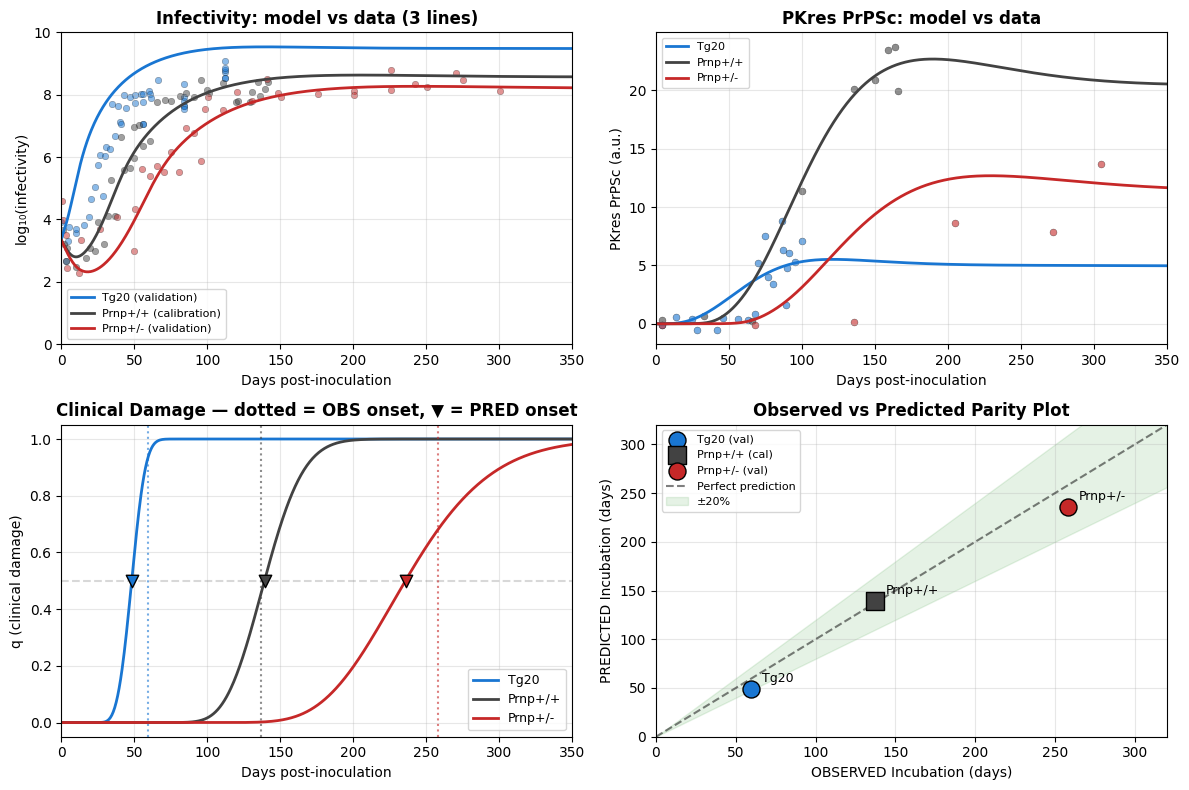

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Panel 1: Infectivity
ax = axes[0,0]

X_wt = predictions['Prnp+/+']['X']
inf_wt = full_dataset[(full_dataset['variable']=='Infectivity_log10') & (full_dataset['line']=='Prnp+/+')]
log_y_wt = np.log10(np.maximum(X_wt[2,:], 1e-30))
iy_wt = np.interp(inf_wt['t_dias'].values, t_sim, log_y_wt)
A_wt = np.vstack([iy_wt, np.ones_like(iy_wt)]).T
alpha_inf, b_inf = np.linalg.lstsq(A_wt, inf_wt['value'].values, rcond=None)[0]

for line, info in lines_info.items():
    X = predictions[line]['X']
    inf_d = full_dataset[(full_dataset['variable']=='Infectivity_log10') & (full_dataset['line']==line)]
    log_y = np.log10(np.maximum(X[2,:], 1e-30))
    if len(inf_d) > 0:
        ax.scatter(inf_d['t_dias'], inf_d['value'], s=22, color=info['color'], alpha=0.5,
                   edgecolor='black', linewidth=0.3)
        role = ' (calibration)' if line=='Prnp+/+' else ' (validation)'
        ax.plot(t_sim, alpha_inf*log_y + b_inf, color=info['color'], lw=2, label=f'{line}{role}')
ax.set_xlabel('Days post-inoculation'); ax.set_ylabel('log₁₀(infectivity)')
ax.set_title('Infectivity: model vs data (3 lines)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlim(0,350); ax.set_ylim(0,10)

# Panel 2: PKres PrPSc
ax = axes[0,1]
for line, info in lines_info.items():
    X = predictions[line]['X']; z = X[3,:]
    pk_d = full_dataset[(full_dataset['variable']=='PKres_PrPSc') & (full_dataset['line']==line)]
    if len(pk_d) > 0:
        pk_grp = pk_d.groupby('t_dias')['value'].median().reset_index()
        iz = np.interp(pk_grp['t_dias'].values, t_sim, z)
        s_z = np.sum(pk_grp['value'].values*iz)/max(np.sum(iz**2),1e-20)
        ax.scatter(pk_grp['t_dias'], pk_grp['value'], s=25, color=info['color'], alpha=0.6,
                   edgecolor='black', linewidth=0.3)
        ax.plot(t_sim, z*s_z, color=info['color'], lw=2, label=line)
ax.set_xlabel('Days post-inoculation'); ax.set_ylabel('PKres PrPSc (a.u.)')
ax.set_title('PKres PrPSc: model vs data', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlim(0,350)

# Panel 3: Clinical damage
ax = axes[1,0]
ax.axhline(0.5, color='gray', ls='--', alpha=0.3)
for line, info in lines_info.items():
    X = predictions[line]['X']
    ax.plot(t_sim, X[6,:], color=info['color'], lw=2, label=line)
    ax.axvline(info['t_inc_obs'], color=info['color'], ls=':', alpha=0.6)
    tp = predictions[line]['t_inc_pred']
    if not np.isnan(tp):
        ax.scatter([tp],[0.5], color=info['color'], s=80, marker='v', edgecolor='black', zorder=5)
ax.set_xlabel('Days post-inoculation'); ax.set_ylabel('q (clinical damage)')
ax.set_title('Clinical Damage — dotted = OBS onset, ▼ = PRED onset', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0,350); ax.set_ylim(-0.05,1.05)

# Panel 4: Parity Plot
ax = axes[1,1]
for line, info in lines_info.items():
    to, tp = predictions[line]['t_inc_obs'], predictions[line]['t_inc_pred']
    if not np.isnan(tp):
        mk = 's' if line=='Prnp+/+' else 'o'
        lbl_role = 'cal' if line=='Prnp+/+' else 'val'
        ax.scatter(to, tp, s=150, color=info['color'], marker=mk, edgecolor='black',
                   linewidth=1, zorder=5, label=f"{line} ({lbl_role})")
        ax.annotate(line, (to, tp), xytext=(8,5), textcoords='offset points', fontsize=9)
lims = [0, 320]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
ax.fill_between(lims, [l*0.8 for l in lims], [l*1.2 for l in lims], alpha=0.1,
                color='green', label='±20%')
ax.set_xlabel('OBSERVED Incubation (days)'); ax.set_ylabel('PREDICTED Incubation (days)')
ax.set_title('Observed vs Predicted Parity Plot', fontweight='bold')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3); ax.set_xlim(lims); ax.set_ylim(lims)
plt.tight_layout()
plt.savefig(OUTDIR / 'fase_g_validacion.png', dpi=800, bbox_inches='tight')
plt.show()

## 5. Results table:

In [ ]:
val_table = pd.DataFrame([{
    'line': l,
    'PrPC_expression': lines_info[l]['expr'],
    't_incub_obs_dias': predictions[l]['t_inc_obs'],
    't_incub_pred_dias': round(predictions[l]['t_inc_pred'],1),
    'error_pct': round(100*(predictions[l]['t_inc_pred']-predictions[l]['t_inc_obs'])/predictions[l]['t_inc_obs'],1),
    'role': 'calibration' if l=='Prnp+/+' else 'validation'
} for l in lines_info])
val_table.to_csv(OUTDIR / 'fase_validacion_tabla.csv', index=False)
val_table

,line,PrPC_expression,t_incub_obs_dias,t_incub_pred_dias,error_pct,role
0,Tg20,8.0,59.5,48.6,-18.2,validation
1,Prnp+/+,1.0,137.0,139.2,1.6,calibration
2,Prnp+/-,0.5,258.0,235.8,-8.6,validation
